## Capstone Project

### 1. Overview
### Question: What are the top factors contributing to a student's mental wellness?


#### 1.1 Business Context
It is important to be able to identify students who may require intervention for their emotional wellbeing. If the question is left unanswered, students who are emotionally unwell may suffer in silence without anyone ever noticing it. With a predictive model capable of identifying potentially emotionally unwell students, emotional and mental wellness institutions can gain insight on factors contributing to depress among students, and the predictive model can flag potentially depressed students to introduce early interventions.

The notebook aims to find a supervised classification machine learning model that can predict students's depress status based on data such as demographics, academic indicators, lifestyle, and other factors to predict whether a student is depressed, and to identify the top 5 drivers impacting a student's emotional wellbeing. 

#### 1.2 Techniques for Analysis
-	Run EDA to examine data distribution.
-	Preprocess data to handle missing values, encode categorical columns, scale numerical columns, and label-encode the categorical outcomes. The data are split into train set, development set, and final test set (70/15/15).
-	Supervised machine learning: Run K Nearest Neighbor, Logistic Regression, Random Forest Classifier, and Support Vector Machine models using Grid Search CV with respected hyperparameters. Tune the hyperparameters and calculate the scores against the development set and find the best model. Finally, evaluate the model using the final hold-out test set.

#### 1.3 Success Criteria
A predictive classification model of more than 70% accuracy (>10% improvement over baseline model) predicting a social media user's dominant emotion, while identifying the top three drivers impacting thedominant emotion. 


### 2. Data Collection and Sourcing

#### 2.1 Data Sourcing

The data is sourced from the Kaggle [website](https://www.kaggle.com/datasets/adilshamim8/student-depress-dataset/data), titled "Student depress Dataset". The dataset has 18 columns and total of 27901 rows, which is adequate for data analysis. Based on Kaggle site, the data was compiled through multiple datasets from OpenML.org, and senstitive information was removed or encoded to achieve anonymity and thus adequate for reasearch purposes.

Feature Description from the Data Source:

- id: A unique identifier assigned to each student record in the dataset..
- Gender: The gender of the student, Male or Female.
- Age: The age of the studnet in years.
- City: The city or region where the student resides, providing geographical context for the analysis.
- Profession: The field of work or study of the student, which may offer insights into occupational or academic stress factors.
- Academic Pressure: A measure indicating the level of pressure the student faces in academic settings. This could include stress from exams, assignments, and overall academic expectations. 0-5.
- Work Pressure: A measure of the pressure related to work or job responsibilities, relevant for students who are employed alongside their studies. 0-5.
- CGPA: The cumulative grade point average of the student, reflecting overall academic performance. 0-10.
- Study Satisfaction: An indicator of how satisfied the student is with their studies, which can correlate with mental well-being. 0-5.
- Job Satisfaction: A measure of the student’s satisfaction with their job or work environment, if applicable.
- Sleep Duration: The average number of hours the student sleeps per day, which is an important factor in mental health. 0-4. Less than 5 hours, 7-8 hours, and Others.
- Dietary Habits: An assessment of the student’s eating patterns and nutritional habits, potentially impacting overall health and mood. Healty, Unhealthy, Moderate, Others.
- Degree: The academic degree or program that the student is pursuing. Various.
- Have you ever had suicidal thoughts ?: A binary indicator (Yes/No) that reflects whether the student has ever experienced suicidal ideation. 
- Work/Study Hours: The average number of hours per day the student dedicates to work or study, which can influence stress levels. 0-12.
- Financial Stress: A measure of the stress experienced due to financial concerns, which may affect mental health. 1-5.
- Family History of Mental Illness: Indicates whether there is a family history of mental illness (Yes/No), which can be a significant factor in mental health predispositions.
- depress: The target variable that indicates whether the student is experiencing depress (Yes/No = 0/1). This is the primary focus of the analysis. 


In [283]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import graphviz

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree

import time
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, RocCurveDisplay
from sklearn.metrics import classification_report, accuracy_score
from sklearn.datasets import make_classification

from sklearn.inspection import permutation_importance
from sklearn import set_config
# Set color scheme
colors = sns.color_palette('Pastel1')
sns.set_palette('Pastel1')

# Supress warnings
import os
os.environ["PYDEVD_DISABLE_FILE_VALIDATION"] = "1"
pd.options.mode.chained_assignment = None # Disable the warning
warnings.simplefilter(action='ignore', category=FutureWarning)
set_config("display")
plt.rcParams.update({'font.size': 12})
RANDOM_STATE = 42

#### 2.2 Read in the Data

I am Combining the 3 datasets into 1 file, so that I can split the train set and test set on my own with all the data combined. There is a major formatting error in the val.csv file, which requires a simple manual fix in Excel in order for the file to load. The file has been edited and saved.

In [2]:
# Read in the file
depress = pd.read_csv('data/student_depression_dataset.csv')

### 3. Exploratory Data Analysis - Initial Inspection

#### 3.1 Initial Inspection

In [3]:
depress.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27901 non-null  int64  
 1   Gender                                 27901 non-null  object 
 2   Age                                    27901 non-null  float64
 3   City                                   27901 non-null  object 
 4   Profession                             27901 non-null  object 
 5   Academic Pressure                      27901 non-null  float64
 6   Work Pressure                          27901 non-null  float64
 7   CGPA                                   27901 non-null  float64
 8   Study Satisfaction                     27901 non-null  float64
 9   Job Satisfaction                       27901 non-null  float64
 10  Sleep Duration                         27901 non-null  object 
 11  Di

In [4]:
depress.isnull().sum().sort_values()

id                                       0
Financial Stress                         0
Work/Study Hours                         0
Have you ever had suicidal thoughts ?    0
Degree                                   0
Dietary Habits                           0
Sleep Duration                           0
Job Satisfaction                         0
Study Satisfaction                       0
CGPA                                     0
Work Pressure                            0
Academic Pressure                        0
Profession                               0
City                                     0
Age                                      0
Gender                                   0
Family History of Mental Illness         0
Depression                               0
dtype: int64

There is no null values.

In [5]:
depress.head()

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,'5-6 hours',Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,'5-6 hours',Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,'Less than 5 hours',Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,'7-8 hours',Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,'5-6 hours',Moderate,M.Tech,Yes,1.0,1.0,No,0


### 4. Exploratory Data Analysis and Data Cleaning

#### 4.1 Feature Examination and Data Cleaning

Drop `id` column because it is not useful.

In [6]:
# Drop 'id' column
depress.drop(columns=['id'], inplace=True)

Define target, categorical and numerical features for EDA.

In [7]:
# Define target column
target = 'Depression'
depress[target] = depress[target].replace(1,"Yes")
depress[target] = depress[target].replace(0,"No")

# Identify numerical and categorical column names
cat_features = depress.select_dtypes(include=["object", "category"]).columns.tolist()
num_features = depress.select_dtypes(include=[np.number]).columns.tolist()
cat_features.remove('Depression') # Remove target variable from categorical features list

Now examine value distribution for each categorical feature.

In [8]:
# Print value distribution for categorical features
for col in cat_features:
    print(f"Value Distribution for {col}:")
    print(depress[col].value_counts(normalize=True))
    print("\n")

Value Distribution for Gender:
Gender
Male      0.55722
Female    0.44278
Name: proportion, dtype: float64


Value Distribution for City:
City
Kalyan                  0.056270
Srinagar                0.049174
Hyderabad               0.048027
Vasai-Virar             0.046235
Lucknow                 0.041396
Thane                   0.040823
Ludhiana                0.039819
Agra                    0.039210
Surat                   0.038637
Kolkata                 0.038207
Jaipur                  0.037131
Patna                   0.036092
Visakhapatnam           0.034730
Pune                    0.034694
Ahmedabad               0.034085
Bhopal                  0.033476
Chennai                 0.031719
Meerut                  0.029569
Rajkot                  0.029246
Delhi                   0.027526
Bangalore               0.027490
Ghaziabad               0.026702
Mumbai                  0.025053
Vadodara                0.024874
Varanasi                0.024551
Nagpur                  0.023332

Based on the output above, we will: 
- Drop the columns `City` and `Degree` because they have too many values, which present challenges for machine learning. Addtionally, `City` has values like `3.0` and `City`,  which are likely errors and cannot be imputed, and `Class 12` accounts for 21.8% of entries in `Degree`.
- For `Profession`, 
    - Drop  the rows with value not equal to `Student` because they represent less than 1 percent of the data.
    - Remove the column entirely because all the values are `Student`. 
- For `Sleep Duration`:
    - Drop the rows with value equal to `Others` because they represent only 0.06 percent of the data.
    - Convert `Less than 5 hours` to `5`.
    - Convert `7-8 hours` to `8`.
    - Convert `5-6 hours` to `6`.
    - Convert `More than 8 hours` to `10`.
    - Convert the data type of the column to numerical.
- For `Dietary Habits`, drop the rows with value equal to `Others` because they represent only 0.04 percent of the data.
- For `Financial Stress`, drop the rows with value equal to`?` because they represent only 0.01 percent of the data, and convert the data type of `Financial Stress` to numerical.
- Rename column `Have you ever had suicidal thoughts ?` to `Has Had Suicidal Thoughts`.
- Re-define `num_features` and `cat_features`.

In [9]:
# Drop City and Degree columns due to high cardinality and low variance
depress.drop(columns=['City', 'Degree'], inplace=True)

# Keep only the rows where "Profession" is "Student" and remove the column since all the values are "Student"
depress = depress[depress['Profession'] == 'Student']
depress.drop(columns=['Profession'], inplace=True)

# Keep only the rows where "Sleep Duration" is not "Others"
depress = depress[depress['Sleep Duration'] != 'Others']

# Convert object values to numeric values in "Sleep Duration" column
depress['Sleep Duration'] = depress['Sleep Duration'].str.replace("Less than 5 hours", '3.5')
depress['Sleep Duration'] = depress['Sleep Duration'].str.replace("7-8 hours", '7.5')
depress['Sleep Duration'] = depress['Sleep Duration'].str.replace("5-6 hours", '5.5')
depress['Sleep Duration'] = depress['Sleep Duration'].str.replace("More than 8 hours", '9.5')
# Strip extra quotes
depress['Sleep Duration'] = depress['Sleep Duration'].astype(str).str.strip("'").astype(float)

# Keep only the rows where "Dietary Habits" is not "Others"
depress = depress[depress['Dietary Habits'] != 'Others']

# Keep only the rows where "Financial Stress" is not "?" and convert the column to numeric values
depress = depress[depress['Financial Stress'] != '?']
depress['Financial Stress'] = pd.to_numeric(depress['Financial Stress'], errors='coerce')

# Rename column `Have you ever had suicidal thoughts ?` to `Has Had Suicidal Thoughts` for better readability
depress.rename(columns={'Have you ever had suicidal thoughts ?': 'Has Had Suicidal Thoughts'}, inplace=True)

# Re-define numerical and categorical column names
cat_features = depress.select_dtypes(include=["object", "category"]).columns.tolist()
num_features = depress.select_dtypes(include=[np.number]).columns.tolist()
cat_features.remove('Depression') # Remove target variable from categorical features list

depress.info()

<class 'pandas.core.frame.DataFrame'>
Index: 27837 entries, 0 to 27900
Data columns (total 14 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Gender                            27837 non-null  object 
 1   Age                               27837 non-null  float64
 2   Academic Pressure                 27837 non-null  float64
 3   Work Pressure                     27837 non-null  float64
 4   CGPA                              27837 non-null  float64
 5   Study Satisfaction                27837 non-null  float64
 6   Job Satisfaction                  27837 non-null  float64
 7   Sleep Duration                    27837 non-null  float64
 8   Dietary Habits                    27837 non-null  object 
 9   Has Had Suicidal Thoughts         27837 non-null  object 
 10  Work/Study Hours                  27837 non-null  float64
 11  Financial Stress                  27837 non-null  float64
 12  Family Hi

#### 4.2 Remove Outliers


Apply IQR to numerical features to remove outliers.

In [10]:
# Remove outliers for numerical columns using IQR method
previous_data_size = depress.shape[0]
for col in num_features: 
    Q1 = depress[col].quantile(0.25)
    Q3 = depress[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    depress = depress[(depress[col] >= lower_bound) & (depress[col] <= upper_bound)]

# Check resulting data after outliers and unreasonable data rows are removed
depress.info()
print(f"\nThis removes {(previous_data_size - depress.shape[0])/previous_data_size*100:.2f}% of the data.")

<class 'pandas.core.frame.DataFrame'>
Index: 27814 entries, 0 to 27900
Data columns (total 14 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Gender                            27814 non-null  object 
 1   Age                               27814 non-null  float64
 2   Academic Pressure                 27814 non-null  float64
 3   Work Pressure                     27814 non-null  float64
 4   CGPA                              27814 non-null  float64
 5   Study Satisfaction                27814 non-null  float64
 6   Job Satisfaction                  27814 non-null  float64
 7   Sleep Duration                    27814 non-null  float64
 8   Dietary Habits                    27814 non-null  object 
 9   Has Had Suicidal Thoughts         27814 non-null  object 
 10  Work/Study Hours                  27814 non-null  float64
 11  Financial Stress                  27814 non-null  float64
 12  Family Hi

The removal of 0.08% data is acceptable (< 5%).

#### 4.3 Categorical Feature Analysis

Check whether target column distribution is balanced or umbalanced.

In [11]:
# Check target variable distribution
depress[target].value_counts(normalize=True)

Depression
Yes    0.585425
No     0.414575
Name: proportion, dtype: float64

The outcome classes are balanced.

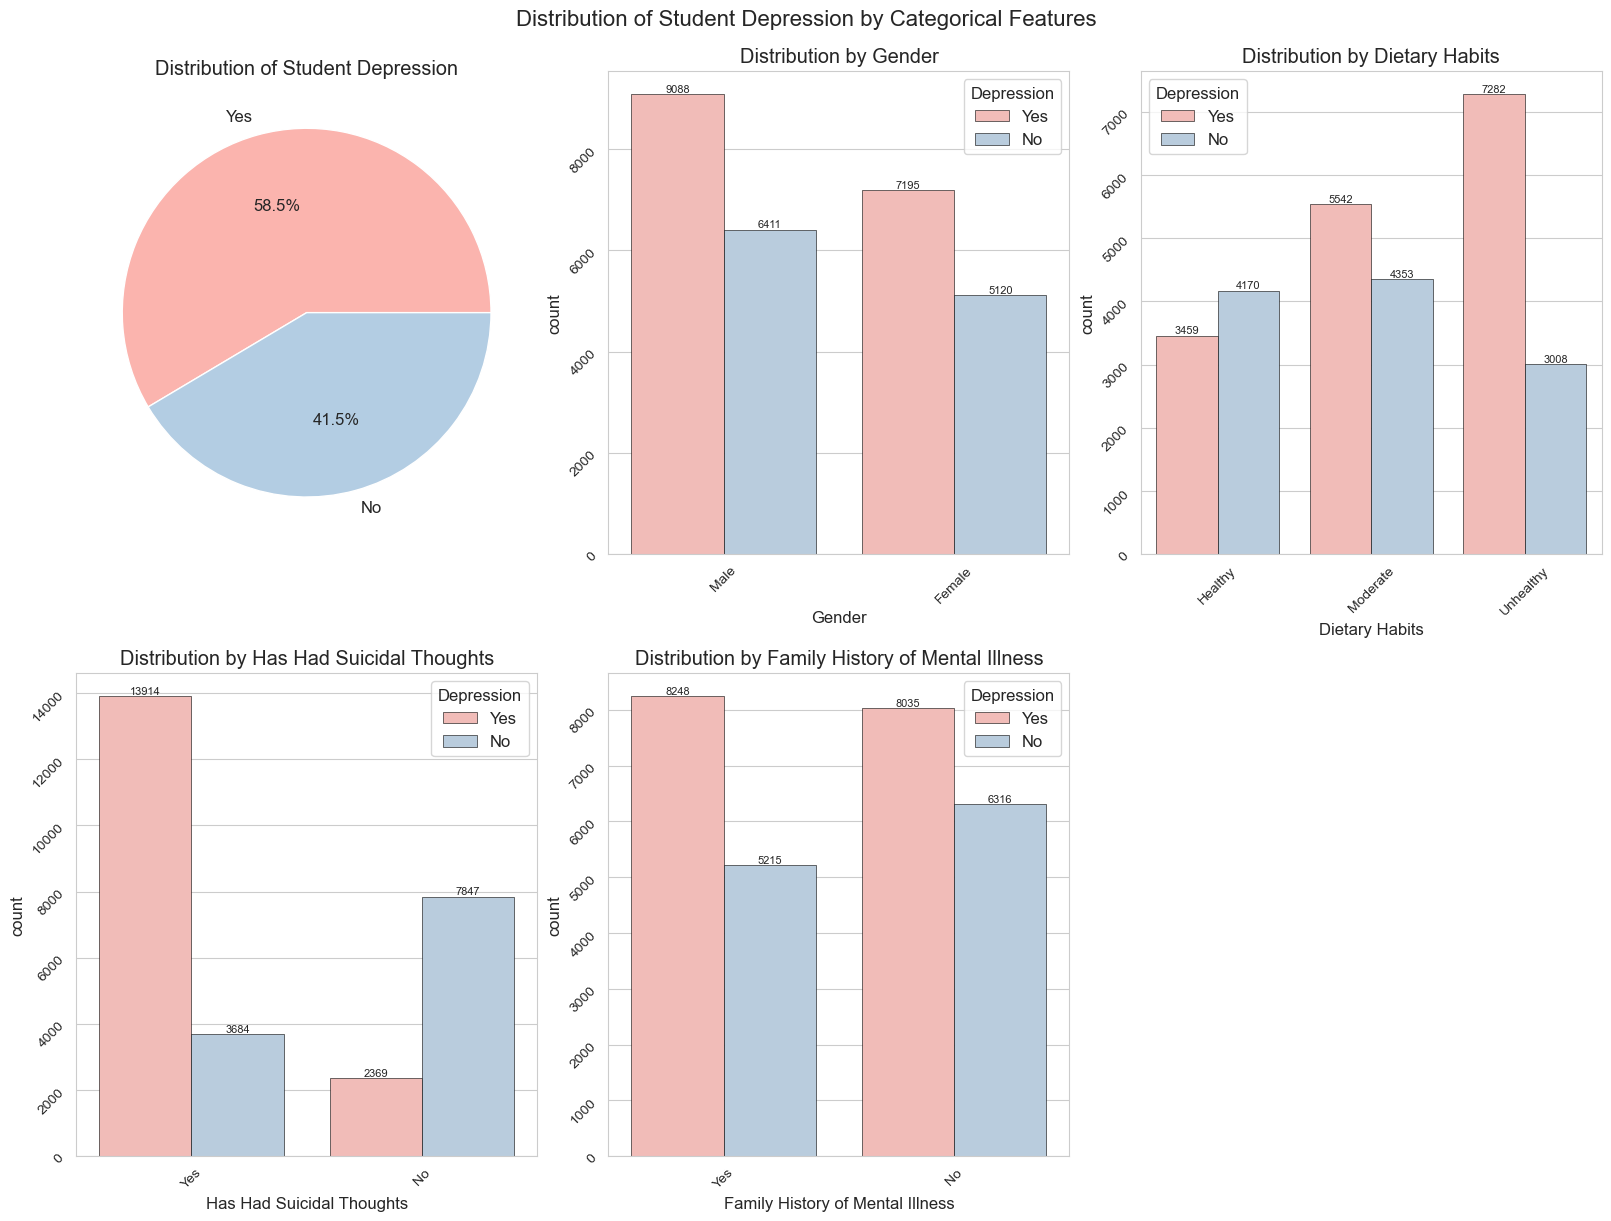

In [270]:
# Convert order of the target column for readability 
depress[target] = pd.Categorical(depress[target], ["Yes", "No"])

# Set up subplots
fig,_axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 12), layout='constrained')
axes=_axes.flatten()

# Delete unused subplot and adjust spacing
fig.delaxes(axes[-1]) 

# Plot distribution of target variable 
axes[0].pie(depress['Depression'].value_counts(), labels=depress['Depression'].value_counts().index, autopct='%1.1f%%', colors=colors)
axes[0].set_title('Distribution of Student Depression')

# Plot distributions of categorical features by target variable
i=1
for col in cat_features:
    order = depress[col].value_counts().index.to_list()
    if (col =='Gender'):
        order = ['Male','Female']
    elif (col == 'Dietary Habits'):
        order = ["Healthy", "Moderate", "Unhealthy"]
    else: 
        order = ["Yes", "No"]
    depress[col] = pd.Categorical(depress[col], order)
    ax = sns.countplot(data=depress, x=col, edgecolor='black', linewidth=0.4, ax=axes[i], hue='Depression')
    for container in ax.containers:
        ax.bar_label(container, label_type='edge',fontsize=8)
    ax.tick_params(labelrotation=45, labelsize=10)
    ax.set_title(f'Distribution by {col}')
    i=i+1
    
plt.suptitle('Distribution of Student Depression by Categorical Features', fontsize=16, verticalalignment='center')
plt.show()

The plot suggests:
- The dataset is a balanced dataset where 58.5% of the students have depression, and 41.5% of the students do not have depression.
- Male and females students do not have a signficant difference in mental wellbeing.
- Those with unhealthy dietary habits tend to be more likely to be depressed.
- Those who have had suicidal thoughts are more likely to be depressed at the present moment.
- Those with a family history of mental illness seem slightly more likely to be depressed. 

#### 4.4 Univariate Analysis for Numerical Features

In [13]:
depress.describe()

,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Work/Study Hours,Financial Stress
count,27814.000000,27814.000000,27814.0,27814.000000,27814.000000,27814.0,27814.000000,27814.000000,27814.000000
mean,25.808981,3.141691,0.0,7.658568,2.943949,0.0,6.298159,7.159704,3.139426
std,4.878918,1.381166,0.0,1.464635,1.360406,0.0,2.253493,3.706372,1.437304
min,18.000000,0.000000,0.0,5.030000,0.000000,0.0,3.500000,0.000000,1.000000
25%,21.000000,2.000000,0.0,6.290000,2.000000,0.0,3.500000,4.000000,2.000000
50%,25.000000,3.000000,0.0,7.770000,3.000000,0.0,5.500000,8.000000,3.000000
75%,30.000000,4.000000,0.0,8.920000,4.000000,0.0,7.500000,10.000000,4.000000
max,43.000000,5.000000,0.0,10.000000,5.000000,0.0,9.500000,12.000000,5.000000


Remove `Work Pressure` and `Job Satisfaction` columns since all the values are 0.

In [15]:
# Remove "Work Pressure" and "Job Satisfaction" columns 
depress.drop(columns=['Work Pressure', 'Job Satisfaction'], inplace=True)

# Convert the column "Work/Study Hours" to "Study Hours" for better readability
depress.rename(columns={'Work/Study Hours': 'Study Hours'}, inplace=True)

# Re-define numerical column names after renaming
num_features = depress.select_dtypes(include=[np.number]).columns.tolist()

Plot distributions of numerical features with histograms.

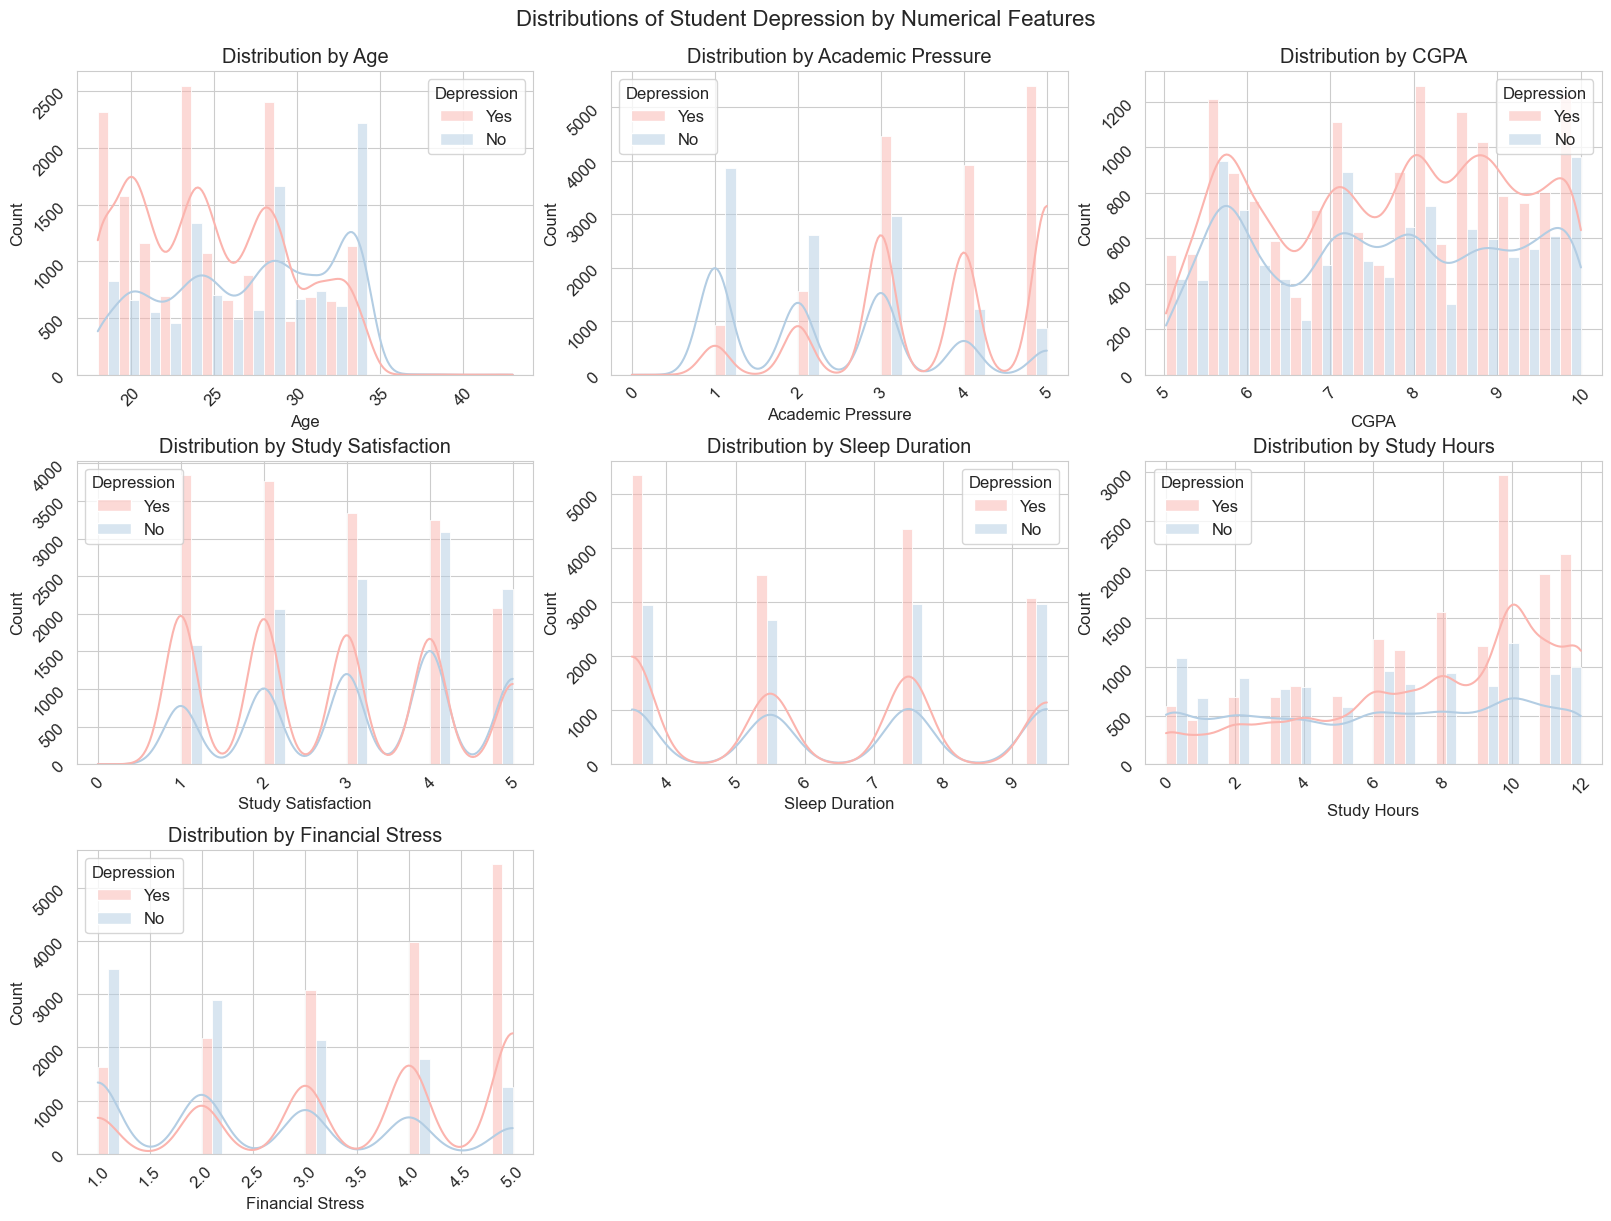

In [254]:
# Set up subplots
fig,_axes = plt.subplots(nrows=3, ncols=3, figsize=(16, 12), layout='constrained')
axes=_axes.flatten()

# Delete unused subplot and adjust spacing
fig.delaxes(axes[-1]) 
fig.delaxes(axes[-2]) 

# Plot the numercial distrubtions with violin plots
i=0
for col in num_features:
    ax = sns.histplot(data =depress, x =col, bins=20, ax=axes[i], multiple='dodge',kde=True, hue = target)
    ax.tick_params(labelrotation=45, labelsize=12)
    ax.set_title(f'Distribution by {col}')
    i=i+1

plt.suptitle('Distributions of Student Depression by Numerical Features', fontsize=16, verticalalignment='center')
plt.show()

Plot numerical data distributions with violin plots to compare distributions of depressed and non-depressed students side by side.

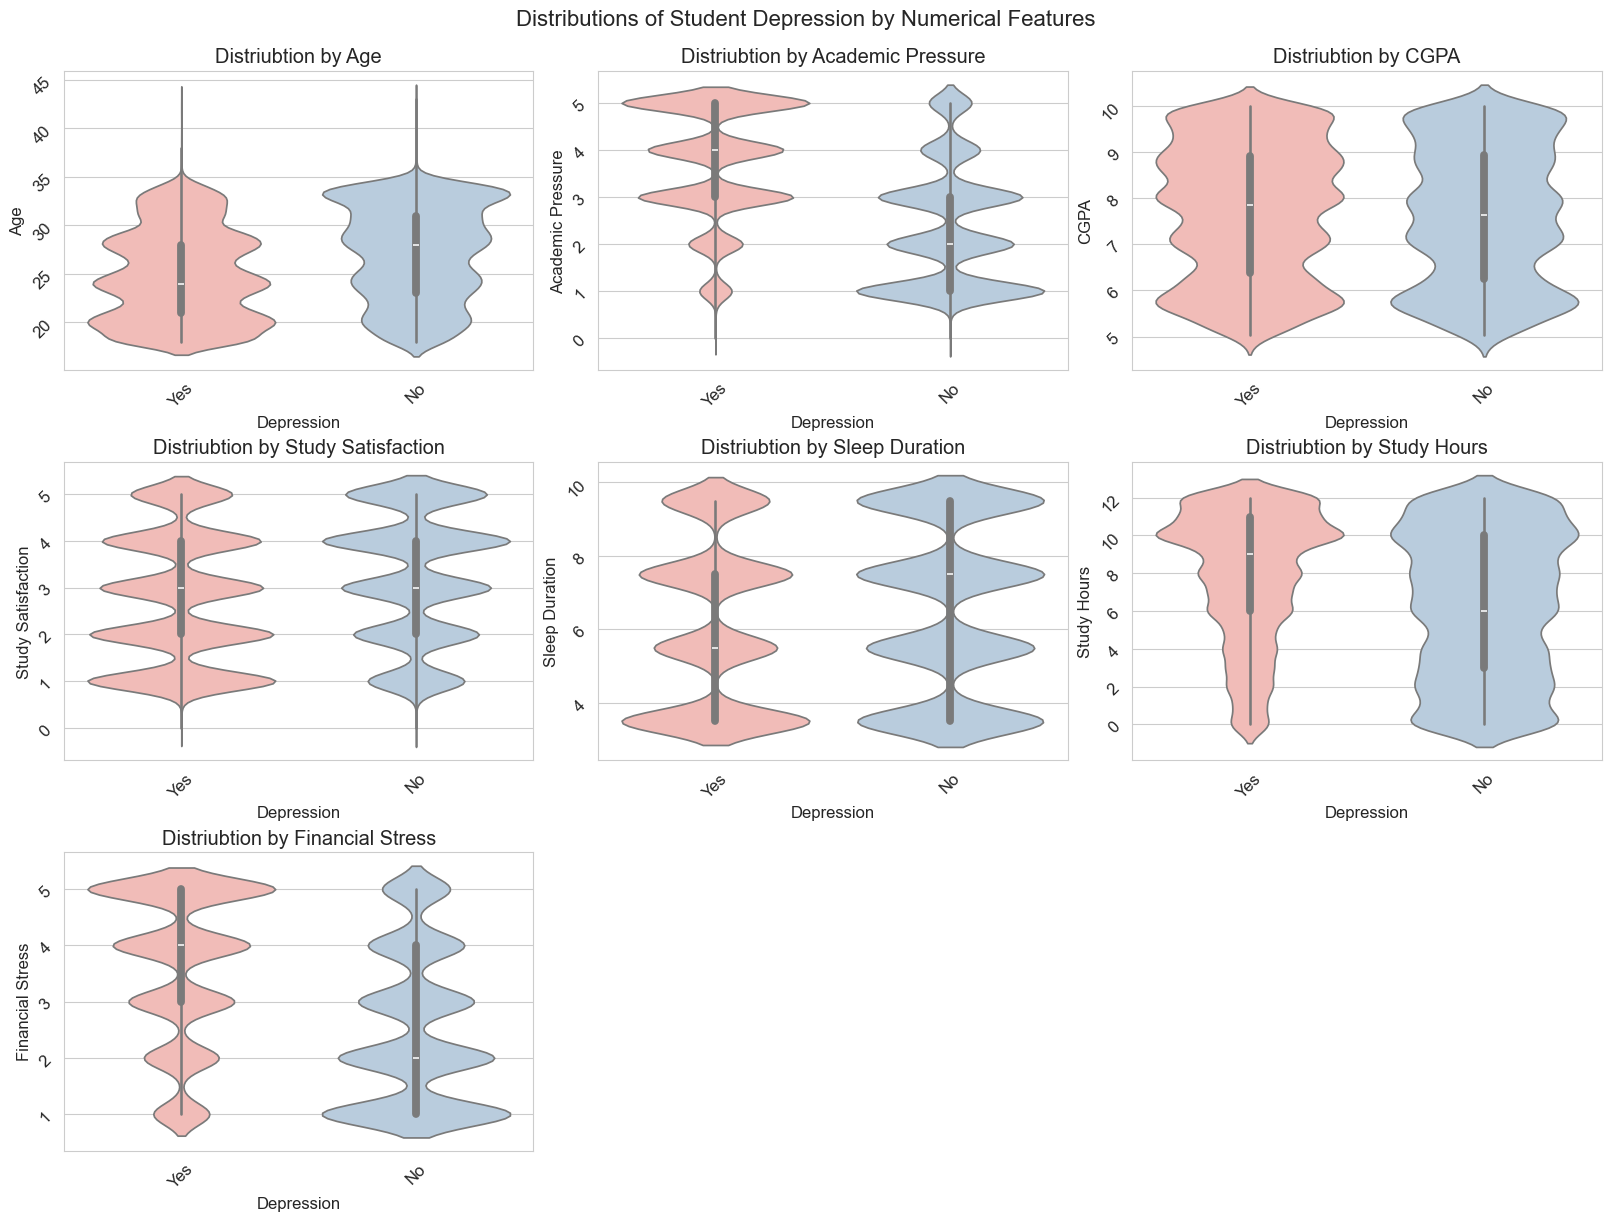

In [37]:
# Set up subplots
fig,_axes = plt.subplots(nrows=3, ncols=3, figsize=(16, 12), layout='constrained')
axes=_axes.flatten()

# Delete unused subplot and adjust spacing
fig.delaxes(axes[-1]) 
fig.delaxes(axes[-2]) 

# Plot the numercial distrubtions with violin plots
i=0
for col in num_features:
    ax = sns.violinplot(data =depress, y =col, ax=axes[i],  x = target , hue=target)
    ax.tick_params(labelrotation=45, labelsize=12)
    ax.set_title(f'Distriubtion by {col}')
    i=i+1


plt.suptitle('Distributions of Student Depression by Numerical Features', fontsize=16, verticalalignment='center')
plt.show()

The univariate analysis suggests:
- Those who are younger may be slightly more prone to depression. 
- Those with higher academic pressure may be more prone to depression.
- Those who sleep less may be more prone to depression.
- Those who study less are less likely to be depressed, but those who study more may not be necessarily depressed.
- Those with higher financial stress may be more prone to depression.
- Study satisfaction and academic performance do not seem to be strong predictors of student depression.

#### 4.5 Bivariate Analysis for Numerical Features

Check correlations between numerical features.

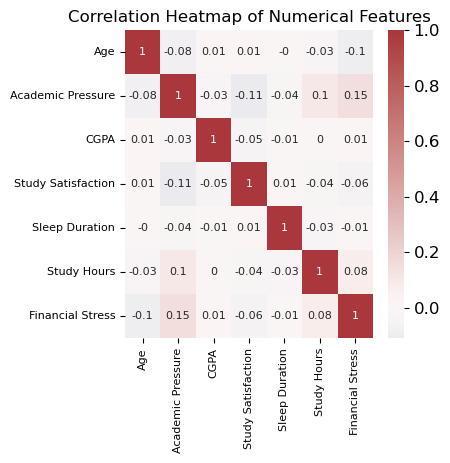

In [169]:
# Correlation heatmap of numerical features
fig, ax = plt.subplots(figsize=(4,4))      
ax = sns.heatmap(round(depress[num_features].corr(), 2), annot=True, center=0,cmap="vlag", annot_kws={'size': 8})
ax.set_xticklabels(ax.get_xticklabels(), fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)
plt.title('Correlation Heatmap of Numerical Features', fontsize=12)
plt.show()

<Figure size 1600x1600 with 0 Axes>

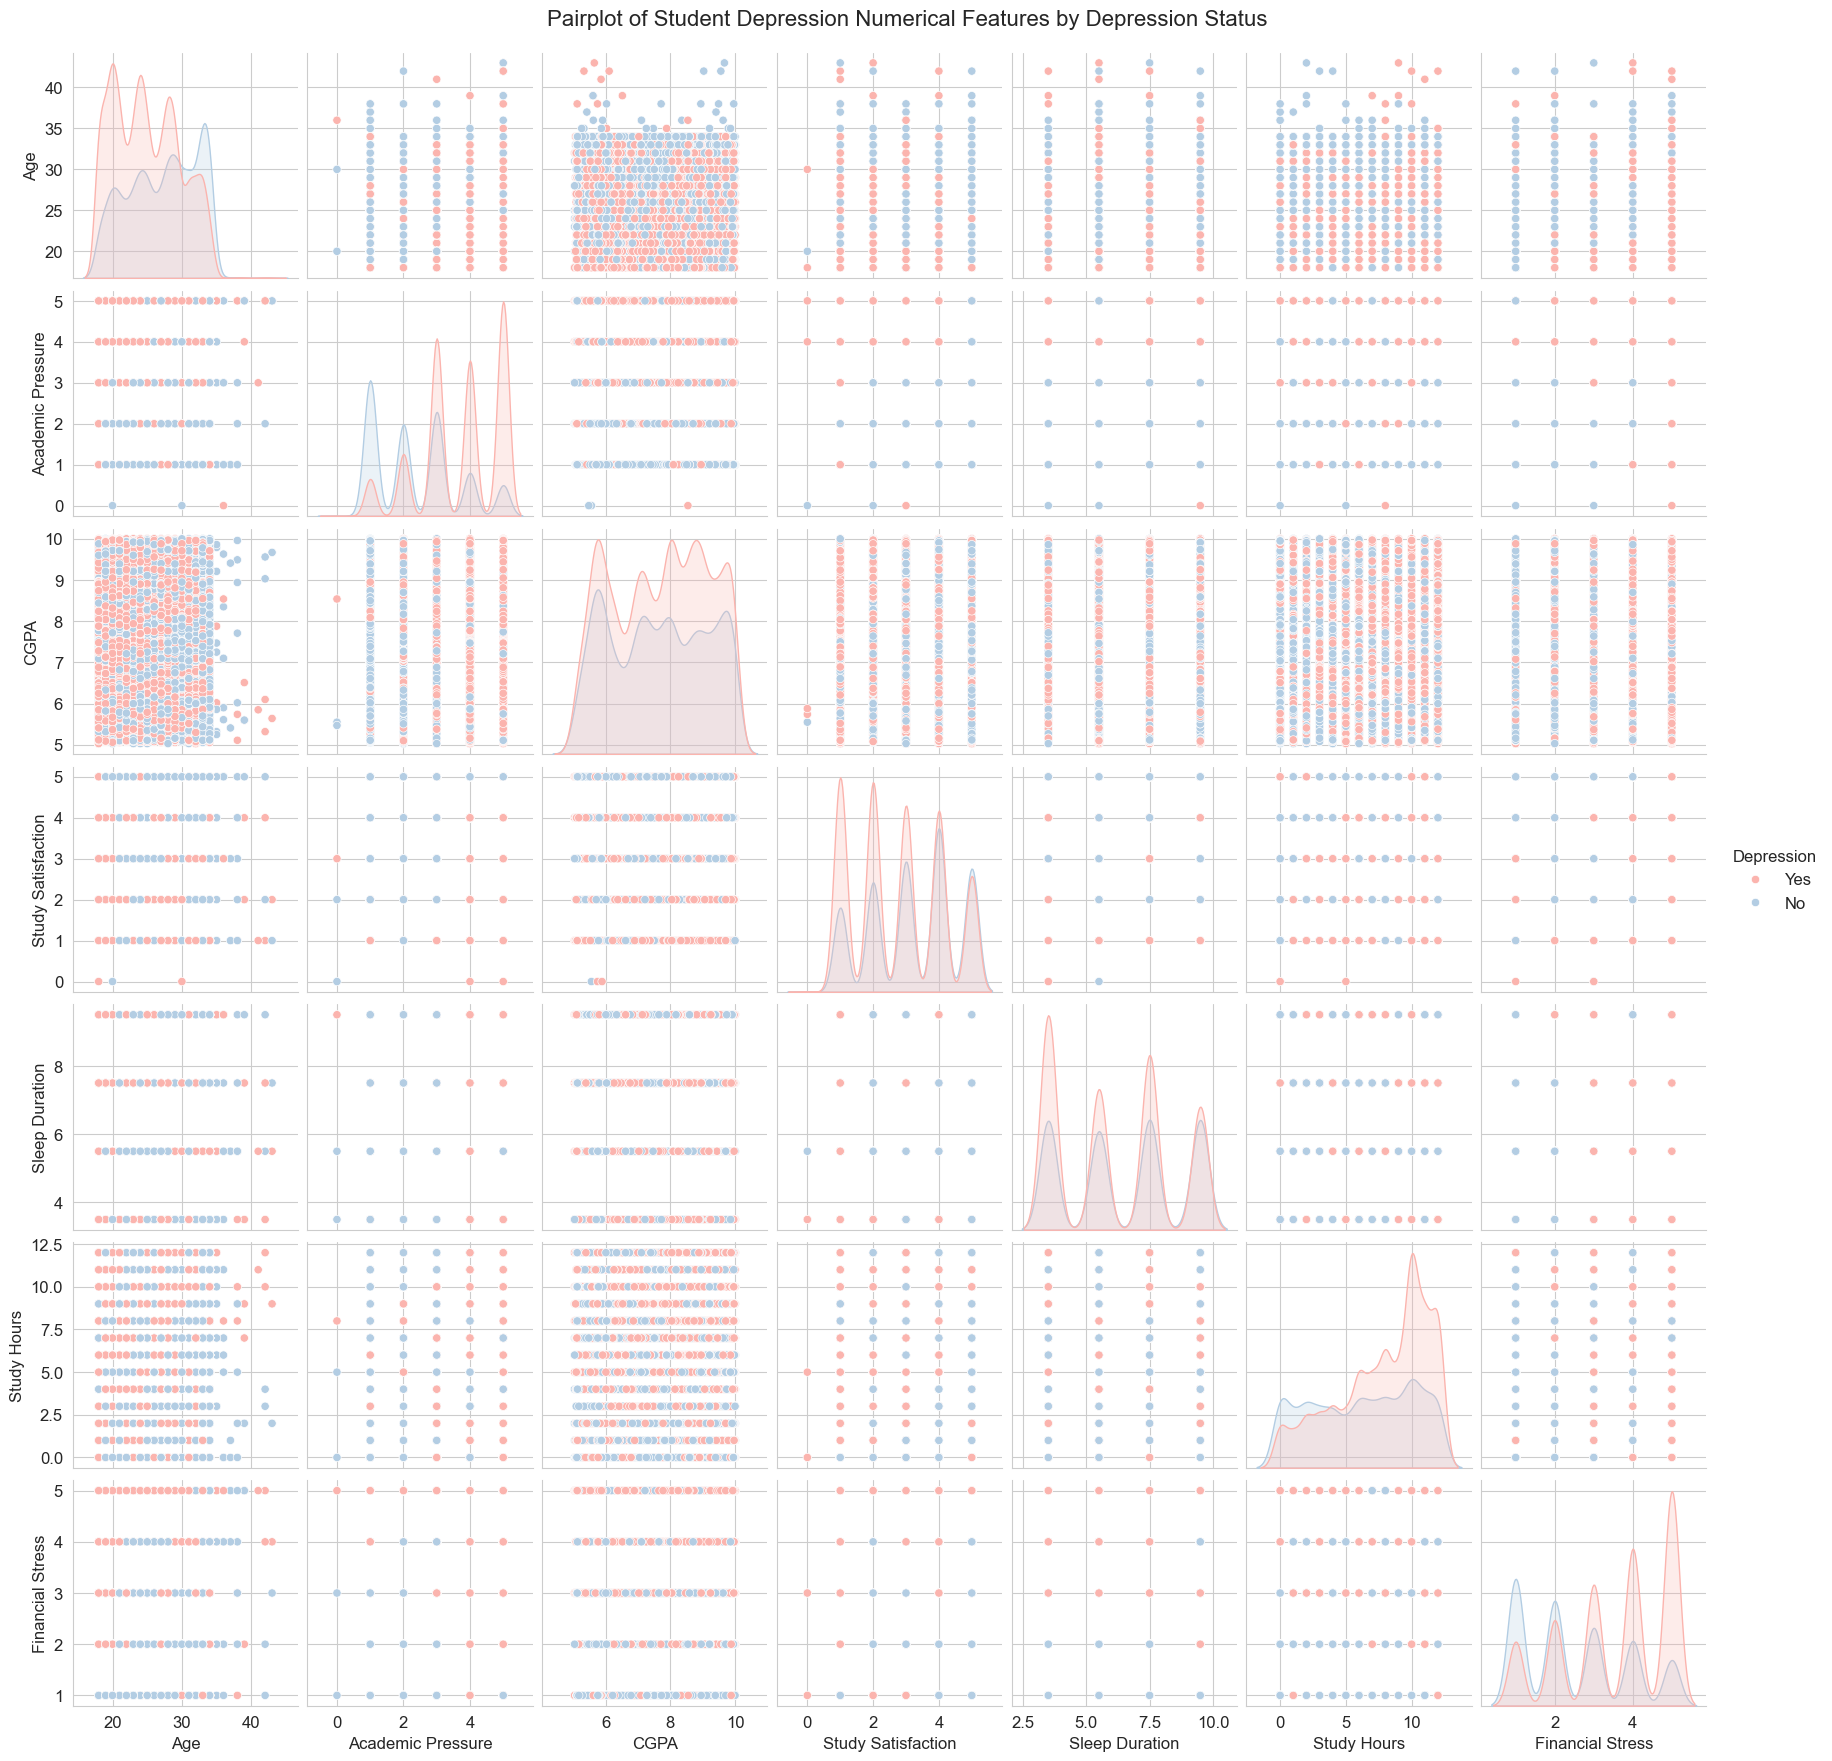

In [ ]:
# Pairplot of numerical features colored by target variable
plt.figure(figsize=(16, 16))
g = sns.pairplot(depress, diag_kind="kde", hue=target)
g.figure.suptitle("Pairplot of Numerical Features by Depression Status", fontsize=16, y=1.01)
plt.show()
plt.show()

The bivariate analysis shows that numerical features do not have significant correlations with one another.

### 5. Feature Engineering

Encode categorical features and scale numerical features.

In [55]:
# Define features (X) and target (y)
X = depress.drop(columns=target)
y = depress[target]

# Encode the target variable
le = LabelEncoder()
y = le.fit_transform(y)

In [56]:
# Define data preprocessing pipelines for numerical and categorical features
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_features),
        ("cat", categorical_transformer, cat_features),
    ],
    remainder="drop"
)

### 6. Data Splitting

In [59]:
# Split the data into training, validation, and test sets (70% train, 15% validation, 15% test)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=RANDOM_STATE)
X_dev, X_test, y_dev, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=RANDOM_STATE)

# Print the sizes of the resulting sets
print(f"Total samples: {len(X)}")
print(f"Train set samples: {len(X_train)} ({len(X_train)/len(X)*100:.0f}%)")
print(f"Development set samples: {len(X_dev)} ({len(X_dev)/len(X)*100:.0f}%)")
print(f"Test set samples: {len(X_test)} ({len(X_test)/len(X)*100:.0f}%)")

Total samples: 27814
Train set samples: 19469 (70%)
Development set samples: 4172 (15%)
Test set samples: 4173 (15%)


### 7. Model Selection

#### 7.1 Baseline Model
A Dummy Classifer wtih majority class as the prediction is chosen as the baseline model.

F1 score is chosen as the metric. While it is more important not to miss those who are depresses because if un-treated, they may deterioate and commit self-harm or suicide, unnecessary follow-up consultations with those who are not in fact depressed may become costly over time. F1 score provides a balance between recall and precision, so that the model would not flag all the students as being depressed. 

In [180]:
# Use a dummy classifier as baseline model

baseline_pipe= Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE))
])

baseline_pipe.fit(X_train, y_train)
train_preds = baseline_pipe.predict(X_train)
dev_preds = baseline_pipe.predict(X_dev)


# Calculate baseline model scores
baseline_train_score = f1_score(y_train, train_preds)
baseline_dev_score = f1_score(y_dev, dev_preds)

#Print baseline model scores
print("Our classifier should perform better than the baseline model performances below:")
print(f"Baseline Train F1 Score: {baseline_train_score:.4}")
print(f"Baseline Development F1 Score: {baseline_dev_score:.4}")

Our classifier should perform better than the baseline model performances below:
Baseline Train F1 Score: 0.7419
Baseline Development F1 Score: 0.7367


Exception ignored in: <function ResourceTracker.__del__ at 0x1037c5b20>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x103981b20>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x106319b20>
Traceback (most recent call last

#### 7.2 Define Models and Initial Hyperparameters

In [121]:
# Define models and hyperparameters
models_1= {
    'Logistic Regression': (LogisticRegression(max_iter=1000), {'Logistic Regression__C': [0.01, 0.1, 1, 10]}),
    'KNN': (KNeighborsClassifier(), {'KNN__n_neighbors': [3, 5, 7, 9]}),
    'Random Forest': (RandomForestClassifier(), {'Random Forest__max_depth': [4, 8, 12, 16], 'Random Forest__n_estimators': [50, 100, 200]}), 
    'SVM': (SVC(), {'SVM__C': [0.1, 1, 10], 'SVM__kernel': ['linear', 'rbf']})
}

### 8. Inital Model Training

In [168]:
results_grid_1 = []
best_models_1 = {}

for name, (model, params) in models_1.items():
    # Create a pipeline
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        (name, model)
    ])
    
    # Perform grid search
    grid = GridSearchCV(pipeline, param_grid=params, cv=5, n_jobs=-1, scoring='f1')
    
    # Fit the model and time it
    start_time = time.time()
    grid = grid.fit(X_train, y_train)
    fit_time = (time.time() - start_time) / len(grid.cv_results_['mean_fit_time'])
    
    # Get the best estimator
    best_models_1[name] = grid.best_estimator_
    best_train_score = grid.best_score_
    best_dev_score = f1_score(y_dev, grid.best_estimator_.predict(X_dev))
    best_params = grid.best_params_

    # Append the results and best model
    results_grid_1.append([name, fit_time, best_train_score, best_dev_score, best_params])


In [169]:
# Set max column width to 100 characters
pd.set_option('display.max_colwidth', 1000)

# Create the results DataFrame
results_grid_1_df = pd.DataFrame(results_grid_1, columns=['Model', 'Train Time (s)', 'Train F1 Score', 'Development F1 Score', 'Best Parameters'])
results_grid_1_df = results_grid_1_df.sort_values(by='Development F1 Score', ascending=False).reset_index(drop=True)
results_grid_1_df

,Model,Train Time (s),Train F1 Score,Development F1 Score,Best Parameters
0,Logistic Regression,1.271603,0.872477,0.871785,{'Logistic Regression__C': 0.01}
1,SVM,10.471503,0.872413,0.871208,"{'SVM__C': 10, 'SVM__kernel': 'linear'}"
2,Random Forest,1.251351,0.867094,0.868220,"{'Random Forest__max_depth': 12, 'Random Forest__n_estimators': 200}"
3,KNN,0.293704,0.862119,0.859310,{'KNN__n_neighbors': 9}


The best model with the intial sets of hyperparameters is Logistic Regression, with Development Set F1 Score of 0.87. There does not seem to be immediate overfitting because the train scores and development scores are very close.

Plot the results to visualize.

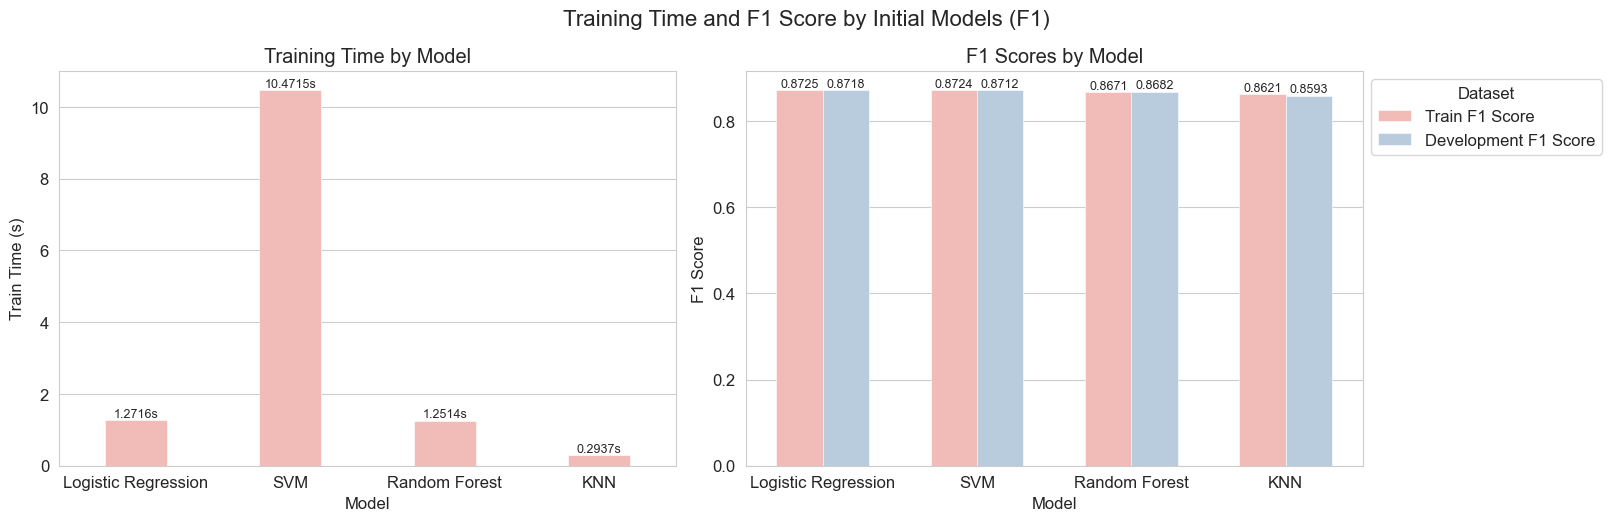

In [171]:
# Set up subplots
fig,_axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 5), layout='constrained')
axes=_axes.flatten()

# Plot training time across models
axes[0] = sns.barplot(x='Model', y='Train Time (s)', linewidth=0.4, data=results_grid_1_df, ax=axes[0], width=0.4)  
axes[0].set_title('Training Time by Model')

for container in axes[0].containers:
        axes[0].bar_label(container,  fmt='{:.4f}s', label_type='edge',fontsize=9)

# Plot training and test accuracy scores
results_grid_1_melted = results_grid_1_df.melt(id_vars='Model', value_vars=['Train F1 Score', 'Development F1 Score'], var_name='Dataset', value_name='F1 Score')
axes[1]=sns.barplot(x='Model', y='F1 Score', hue='Dataset', linewidth=0.4, data=results_grid_1_melted, ax=axes[1], width=0.6)
axes[1].set_title('F1 Scores by Model')
# axes[1].tick_params(labelrotation=45)
for container in axes[1].containers:
        axes[1].bar_label(container,  fmt='{:.4f}', label_type='edge',fontsize=9)
sns.move_legend(axes[1], "best", bbox_to_anchor=(1, 1), title="Dataset")
plt.suptitle('Training Time and F1 Score by Initial Models (F1)', fontsize=16, verticalalignment='center')
plt.show()

### 9. Hyperparameter Tuning
#### 9.1 First Round of Hyperparameter Tuning

Based on the output from the initial model, the hyperparameters are modified to see if the recall scores can be improved.

In [125]:
# New hyperparameters
models_2 = {
    'Logistic Regression': (LogisticRegression(max_iter=1000), {'Logistic Regression__C': [0.001, 0.01, 0.1, 1, 10]}),
    'KNN': (KNeighborsClassifier(), {'KNN__n_neighbors': range(1,31)}),
    'Random Forest': (RandomForestClassifier(), {'Random Forest__max_depth': [15, 20, 25, 30], 'Random Forest__n_estimators': [50, 100, 200, 500]}), 
    'SVM': (SVC(), {'SVM__C': [0.001, 0.01, 0.1, 1, 10], 'SVM__kernel': ['linear', 'rbf']})
}

In [172]:
results_grid_2 = []
best_models_2 = {}

for name, (model, params) in models_2.items():
    # Create a pipeline
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        (name, model)
    ])
    
    # Perform grid search
    grid = GridSearchCV(pipeline, param_grid=params, cv=5, n_jobs=-1, scoring='f1')
    
    # Fit the model and time it
    start_time = time.time()
    grid = grid.fit(X_train, y_train)
    fit_time = (time.time() - start_time) / len(grid.cv_results_['mean_fit_time'])
    
    # Get the best estimator
    best_models_2[name] = grid.best_estimator_
    best_train_score = grid.best_score_
    best_dev_score = f1_score(y_dev, grid.best_estimator_.predict(X_dev))
    best_params = grid.best_params_

    # Append the results and best model
    results_grid_2.append([name, fit_time, best_train_score, best_dev_score, best_params])


In [173]:
# Create the results DataFrame
results_grid_2_df = pd.DataFrame(results_grid_2, columns=['Model', 'Train Time (s)', 'Train F1 Score', 'Development F1 Score', 'Best Parameters'])
results_grid_2_df = results_grid_2_df.sort_values(by='Development F1 Score', ascending=False).reset_index(drop=True)
results_grid_2_df

,Model,Train Time (s),Train F1 Score,Development F1 Score,Best Parameters
0,SVM,7.813505,0.873165,0.872756,"{'SVM__C': 0.001, 'SVM__kernel': 'linear'}"
1,Logistic Regression,0.125692,0.872477,0.871785,{'Logistic Regression__C': 0.01}
2,KNN,0.311990,0.870150,0.869754,{'KNN__n_neighbors': 29}
3,Random Forest,3.610807,0.866039,0.863518,"{'Random Forest__max_depth': 15, 'Random Forest__n_estimators': 100}"


The best model after hyperparameter tuning is SVM with development F1 score of 0.8728, which is better than the F1 score of 0.8718 from the previous Logistic Regression model.

Plot the fit time and performance across models.

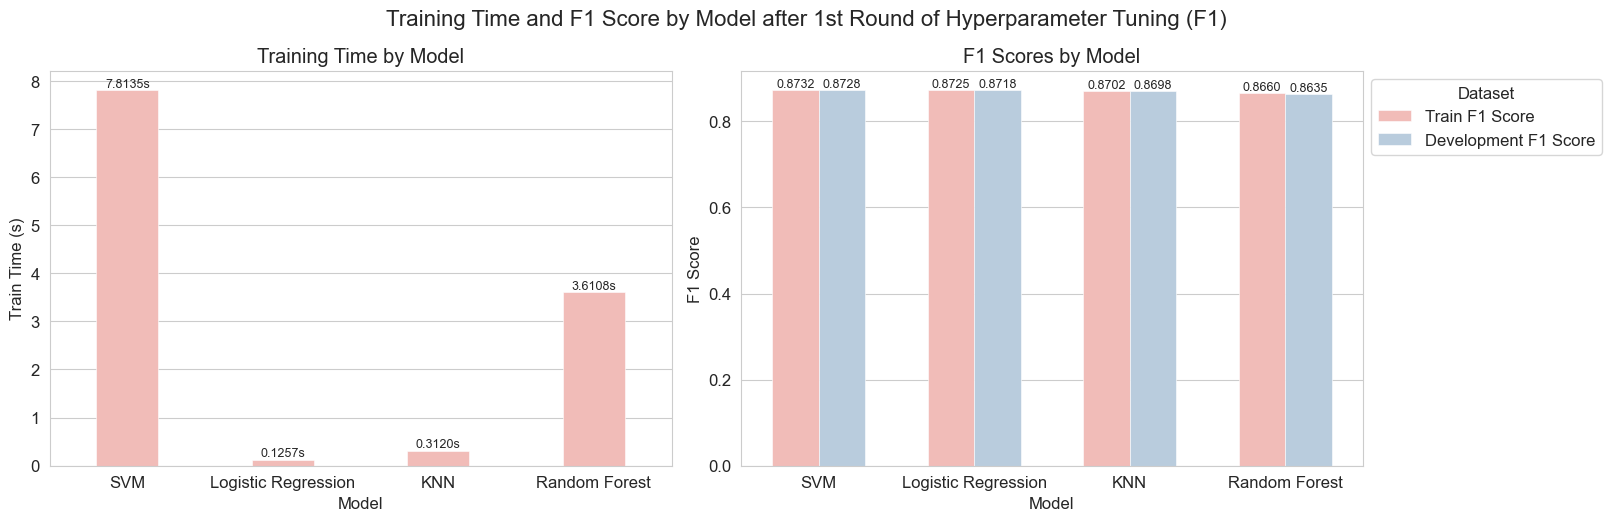

In [176]:
# Set up subplots
fig,_axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 5), layout='constrained')
axes=_axes.flatten()

# Plot training time across models
axes[0] = sns.barplot(x='Model', y='Train Time (s)', linewidth=0.4, data=results_grid_2_df, ax=axes[0], width=0.4)  
axes[0].set_title('Training Time by Model')
# axes[0].tick_params(labelrotation=45)
for container in axes[0].containers:
        axes[0].bar_label(container,  fmt='{:.4f}s', label_type='edge',fontsize=9)

# Plot training and test accuracy scores
results_grid_2_melted = results_grid_2_df.melt(id_vars='Model', value_vars=['Train F1 Score', 'Development F1 Score'], var_name='Dataset', value_name='F1 Score')
axes[1]=sns.barplot(x='Model', y='F1 Score', hue='Dataset', linewidth=0.4, data=results_grid_2_melted, ax=axes[1], width=0.6)
axes[1].set_title('F1 Scores by Model')
# axes[1].tick_params(labelrotation=45)
for container in axes[1].containers:
        axes[1].bar_label(container,  fmt='{:.4f}', label_type='edge',fontsize=9)
sns.move_legend(axes[1], "best", bbox_to_anchor=(1, 1), title="Dataset")
plt.suptitle('Training Time and F1 Score by Model after 1st Round of Hyperparameter Tuning (F1)', fontsize=16, verticalalignment='center')
plt.show()

#### 9.2 Second Round of Hyperparameter Tuning

To improve the SVM model further, modify SVM hyperparameters by adding gamma values and using only RBF kernel.

In [175]:
# Start with previous results because only the SVM model has new hyperparameters 
results_grid_3 = results_grid_2.copy() 
best_models_3 = best_models_2.copy() 

# Create a pipeline for SVM with the new hyperparameters
name = 'SVM'
params = {'SVM__C': [0.0001, 0.001, 0.01, 0.1, 1, 10], 'SVM__gamma': [2**(-14), 2**(-13), 2**(-12), 2**(-11)]}

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    (name, SVC(kernel = 'rbf'))
])

# Perform grid search
grid = GridSearchCV(pipeline, param_grid=params, cv=5, n_jobs=-1, scoring='f1')

# Fit the model and time it
start_time = time.time()
grid = grid.fit(X_train, y_train)
fit_time = (time.time() - start_time) / len(grid.cv_results_['mean_fit_time'])
    
# Update the best estimator
best_models_3[name] = grid.best_estimator_
best_train_score = grid.best_score_
best_dev_score = f1_score(y_dev, grid.best_estimator_.predict(X_dev))
best_params = grid.best_params_

results_grid_3[3] = ([name, fit_time, best_train_score, best_dev_score, best_params])

The final parameters tried for the models are: 

- Logistic Regression
    - max_iter = 1000
    - C: [0.001, 0.01, 0.1, 1, 10]
- KNN
    - n_neighbors: range (1,31)
- Random Forest
    - max_depth: [15, 20, 25, 30]
    - n_estimators: [50, 100, 200, 500]
- SVM
    - kernel = 'rbf' 
    - C: [0.0001, 0.001, 0.01, 0.1, 1, 10]
    - gamma: [2**(-14), 2**(-13), 2**(-12), 2**(-11)]

In [177]:
# Create the results DataFrame
results_grid_3_df = pd.DataFrame(results_grid_3, columns=['Model', 'Train Time (s)', 'Train F1 Score', 'Development F1 Score', 'Best Parameters'])
results_grid_3_df = results_grid_3_df.sort_values(by='Development F1 Score', ascending=False).reset_index(drop=True)
results_grid_3_df

,Model,Train Time (s),Train F1 Score,Development F1 Score,Best Parameters
0,SVM,8.532068,0.874234,0.873870,"{'SVM__C': 1, 'SVM__gamma': 0.0001220703125}"
1,Logistic Regression,0.125692,0.872477,0.871785,{'Logistic Regression__C': 0.01}
2,KNN,0.311990,0.870150,0.869754,{'KNN__n_neighbors': 29}
3,Random Forest,3.610807,0.866039,0.863518,"{'Random Forest__max_depth': 15, 'Random Forest__n_estimators': 100}"


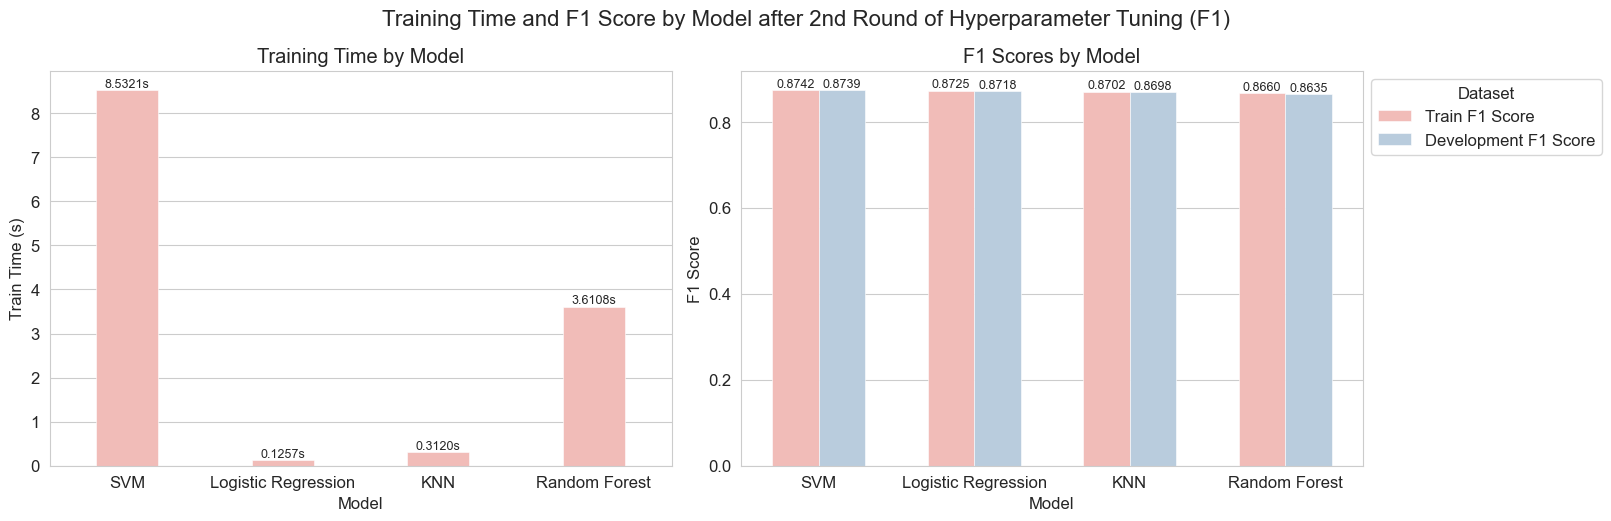

In [178]:
# Set up subplots
fig,_axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 5), layout='constrained')
axes=_axes.flatten()

# Plot training time across models
axes[0] = sns.barplot(x='Model', y='Train Time (s)', linewidth=0.4, data=results_grid_3_df, ax=axes[0], width=0.4)  
axes[0].set_title('Training Time by Model')
# axes[0].tick_params(labelrotation=45)
for container in axes[0].containers:
        axes[0].bar_label(container,  fmt='{:.4f}s', label_type='edge',fontsize=9)

# Plot training and test accuracy scores
results_grid_3_melted = results_grid_3_df.melt(id_vars='Model', value_vars=['Train F1 Score', 'Development F1 Score'], var_name='Dataset', value_name='F1 Score')
axes[1]=sns.barplot(x='Model', y='F1 Score', hue='Dataset', linewidth=0.4, data=results_grid_3_melted, ax=axes[1], width=0.6)
axes[1].set_title('F1 Scores by Model')
# axes[1].tick_params(labelrotation=45)
for container in axes[1].containers:
        axes[1].bar_label(container,  fmt='{:.4f}', label_type='edge',fontsize=9)
sns.move_legend(axes[1], "best", bbox_to_anchor=(1, 1), title="Dataset")
plt.suptitle('Training Time and F1 Score by Model after 2nd Round of Hyperparameter Tuning (F1)', fontsize=16, verticalalignment='center')
plt.show()

In [179]:
# Choose the best model
final_model = best_models_3[results_grid_3_df['Model'][0]]
final_model_name = results_grid_3_df['Model'][0]
print("The best model is", final_model_name, "because it has the highest Development F1 Score of", \
      f"{results_grid_3_df['Development F1 Score'][0]:.4f}.")

The best model is SVM because it has the highest Development F1 Score of 0.8739.




The new best SVM model achieves a F1 score of 0.8739 for the development set. Although it takes the longest time to train, it has the highest F1 score for the development set compared to KNN, Logistic Regression, and Random Forest.

The best model (F1 = 0.8739) performs 18.62% better than the baseline model (F1 = 0.7367).


Here is the best parameter combination of the best SVM model:
- C = 1
- gamma = 0.0001220703125
- kernel = RBF

10. Model Evaluation
- Classification
    - Accuracy, Precision, Recall, F1, ROC-AUC, confusion matrix.
    
- Go beyond metrics:
    - Analyze misclassifications
    - Segment performance (fairness across groups)
    - Error patterns


### 10. Model Evaluation with Test Set

#### 10.1 Classification Report

In [256]:
# Predict on the test set using the final model
final_train_preds = final_model.predict(X_train)
final_dev_preds = final_model.predict(X_dev)

In [257]:
# Generate the classification report 
report_dict = classification_report(y_dev, final_dev_preds, target_names= ['Not Depressed', 'Depressed'])
print (report_dict)

               precision    recall  f1-score   support

Not Depressed       0.86      0.75      0.80      1739
    Depressed       0.84      0.91      0.87      2433

     accuracy                           0.85      4172
    macro avg       0.85      0.83      0.84      4172
 weighted avg       0.85      0.85      0.84      4172



The F1-score of the test set with the final model is 0.87, which is consistent with the F1-score of the development set. The recall score (0.92) is greater than the precision score (0.83), which is desirable because it is less likely to produce a false negative. 

#### 10.2 Confusion Matrix and ROC-AUC Curve

Predicted Depression Rate of Train Set: 64.33%
Predicted Depression Rate of Development Set: 63.69%
Actual Depression Rate of Train Set: 58.97%
Actual Depression Rate of Development Set: 58.32%

Final Selected Model - SVM:


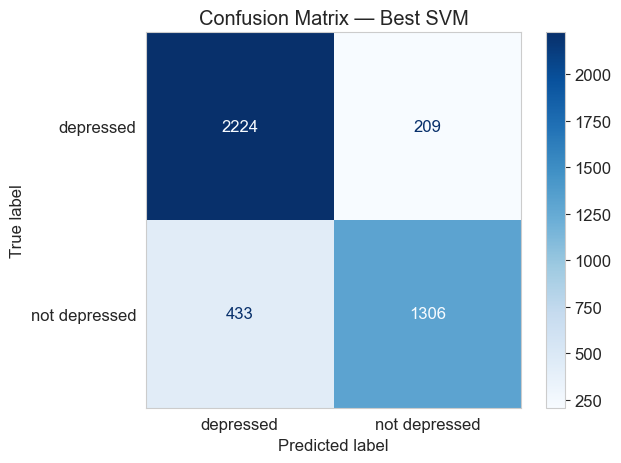

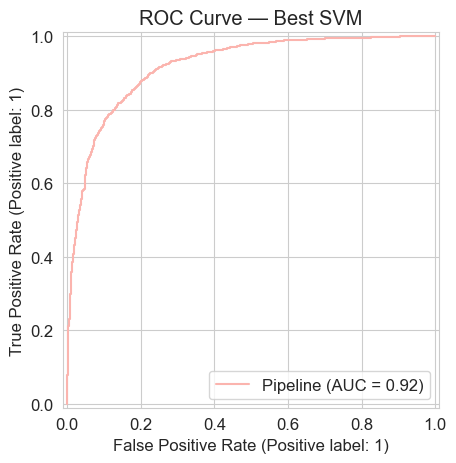

In [258]:
# Print predicted and actual depression status
final_train_pred_rate = sum(final_train_preds)/len(final_train_preds)
final_dev_pred_rate = sum(final_dev_preds)/len(final_dev_preds)
actual_train_rate = sum(y_train)/len(y_train)
actual_dev_rate = sum(y_dev)/len(y_dev)
print(f"Predicted Depression Rate of Train Set: {final_train_pred_rate:.2%}")
print(f"Predicted Depression Rate of Development Set: {final_dev_pred_rate:.2%}")
print(f"Actual Depression Rate of Train Set: {actual_train_rate:.2%}")
print(f"Actual Depression Rate of Development Set: {actual_dev_rate:.2%}")
print(f"\nFinal Selected Model - {final_model_name}:")

# Confusion matrix
fig, ax = plt.subplots()
ax.grid(False) 
confusion_mat = confusion_matrix(y_dev, final_dev_preds, labels=[1, 0])
disp_cf = ConfusionMatrixDisplay(confusion_matrix=confusion_mat, display_labels=['depressed', 'not depressed'])
disp_cf.plot(cmap=plt.cm.Blues, values_format='d', ax=ax)
plt.title(f"Confusion Matrix — Best {final_model_name}")
plt.tight_layout()
plt.show()

# ROC Curve
disp_roc =RocCurveDisplay.from_estimator(final_model, X_dev, y_dev)
plt.title(f"ROC Curve — Best {final_model_name}")
plt.tight_layout()
plt.show()

- Using the development set, the predicted depression rate is 63.69%, which is greater than the acctual depression rate of 58.32%.
- The confusion matrix also confirms that the model is less likely to produce a false negative (209) than a false positive (433).
- The AUC score is 0.92, which is high (> 0.9).

#### 10.3 Analysis of Misclassifications
Examine data which are misclassified to see if error patterns can be found.

Create a copoy of the Development set, and add `Actual Depresion`, `Predicted Depression`, and `Model Prediction` columns.

In [275]:
# Examine the rows where final_test_preds and y_test are different to understand the misclassifications by creating a new DataFrame with a new column indicating whether the prediction was correct or not.
misclassified = X_dev.copy()
misclassified['Actual Depression'] = y_dev
misclassified['Predicted Depression'] = final_dev_preds
misclassified['Model Prediction'] = misclassified['Actual Depression'] == misclassified['Predicted Depression']
misclassified['Model Prediction'] = misclassified['Model Prediction'].map({True: 'Correct', False: 'Misclassified'})
misclassified.sample(10)


,Gender,Age,Academic Pressure,CGPA,Study Satisfaction,Sleep Duration,Dietary Habits,Has Had Suicidal Thoughts,Study Hours,Financial Stress,Family History of Mental Illness,Actual Depression,Predicted Depression,Model Prediction
15026,Male,18.0,3.0,5.37,4.0,3.5,Unhealthy,Yes,9.0,4.0,Yes,1,1,Correct
11632,Female,25.0,4.0,8.83,1.0,9.5,Healthy,No,3.0,2.0,No,0,0,Correct
24116,Female,19.0,5.0,5.99,2.0,7.5,Moderate,Yes,8.0,3.0,Yes,1,1,Correct
26926,Male,23.0,2.0,6.29,1.0,3.5,Unhealthy,No,10.0,5.0,No,0,1,Misclassified
2891,Male,32.0,2.0,9.13,3.0,7.5,Healthy,No,7.0,3.0,No,0,0,Correct
25101,Female,19.0,5.0,7.64,2.0,3.5,Moderate,Yes,10.0,4.0,Yes,1,1,Correct
15612,Male,29.0,2.0,5.27,4.0,3.5,Moderate,Yes,2.0,4.0,Yes,0,1,Misclassified
25512,Female,23.0,3.0,8.98,4.0,7.5,Healthy,Yes,5.0,3.0,Yes,1,1,Correct
7760,Male,24.0,1.0,7.51,5.0,7.5,Unhealthy,No,0.0,2.0,Yes,0,0,Correct
4508,Female,33.0,4.0,9.39,4.0,7.5,Moderate,No,6.0,1.0,No,0,0,Correct


Plot distributions of features by model prediction result to see if the distributions of correctly classified and misclassified data exhibit different patterns.

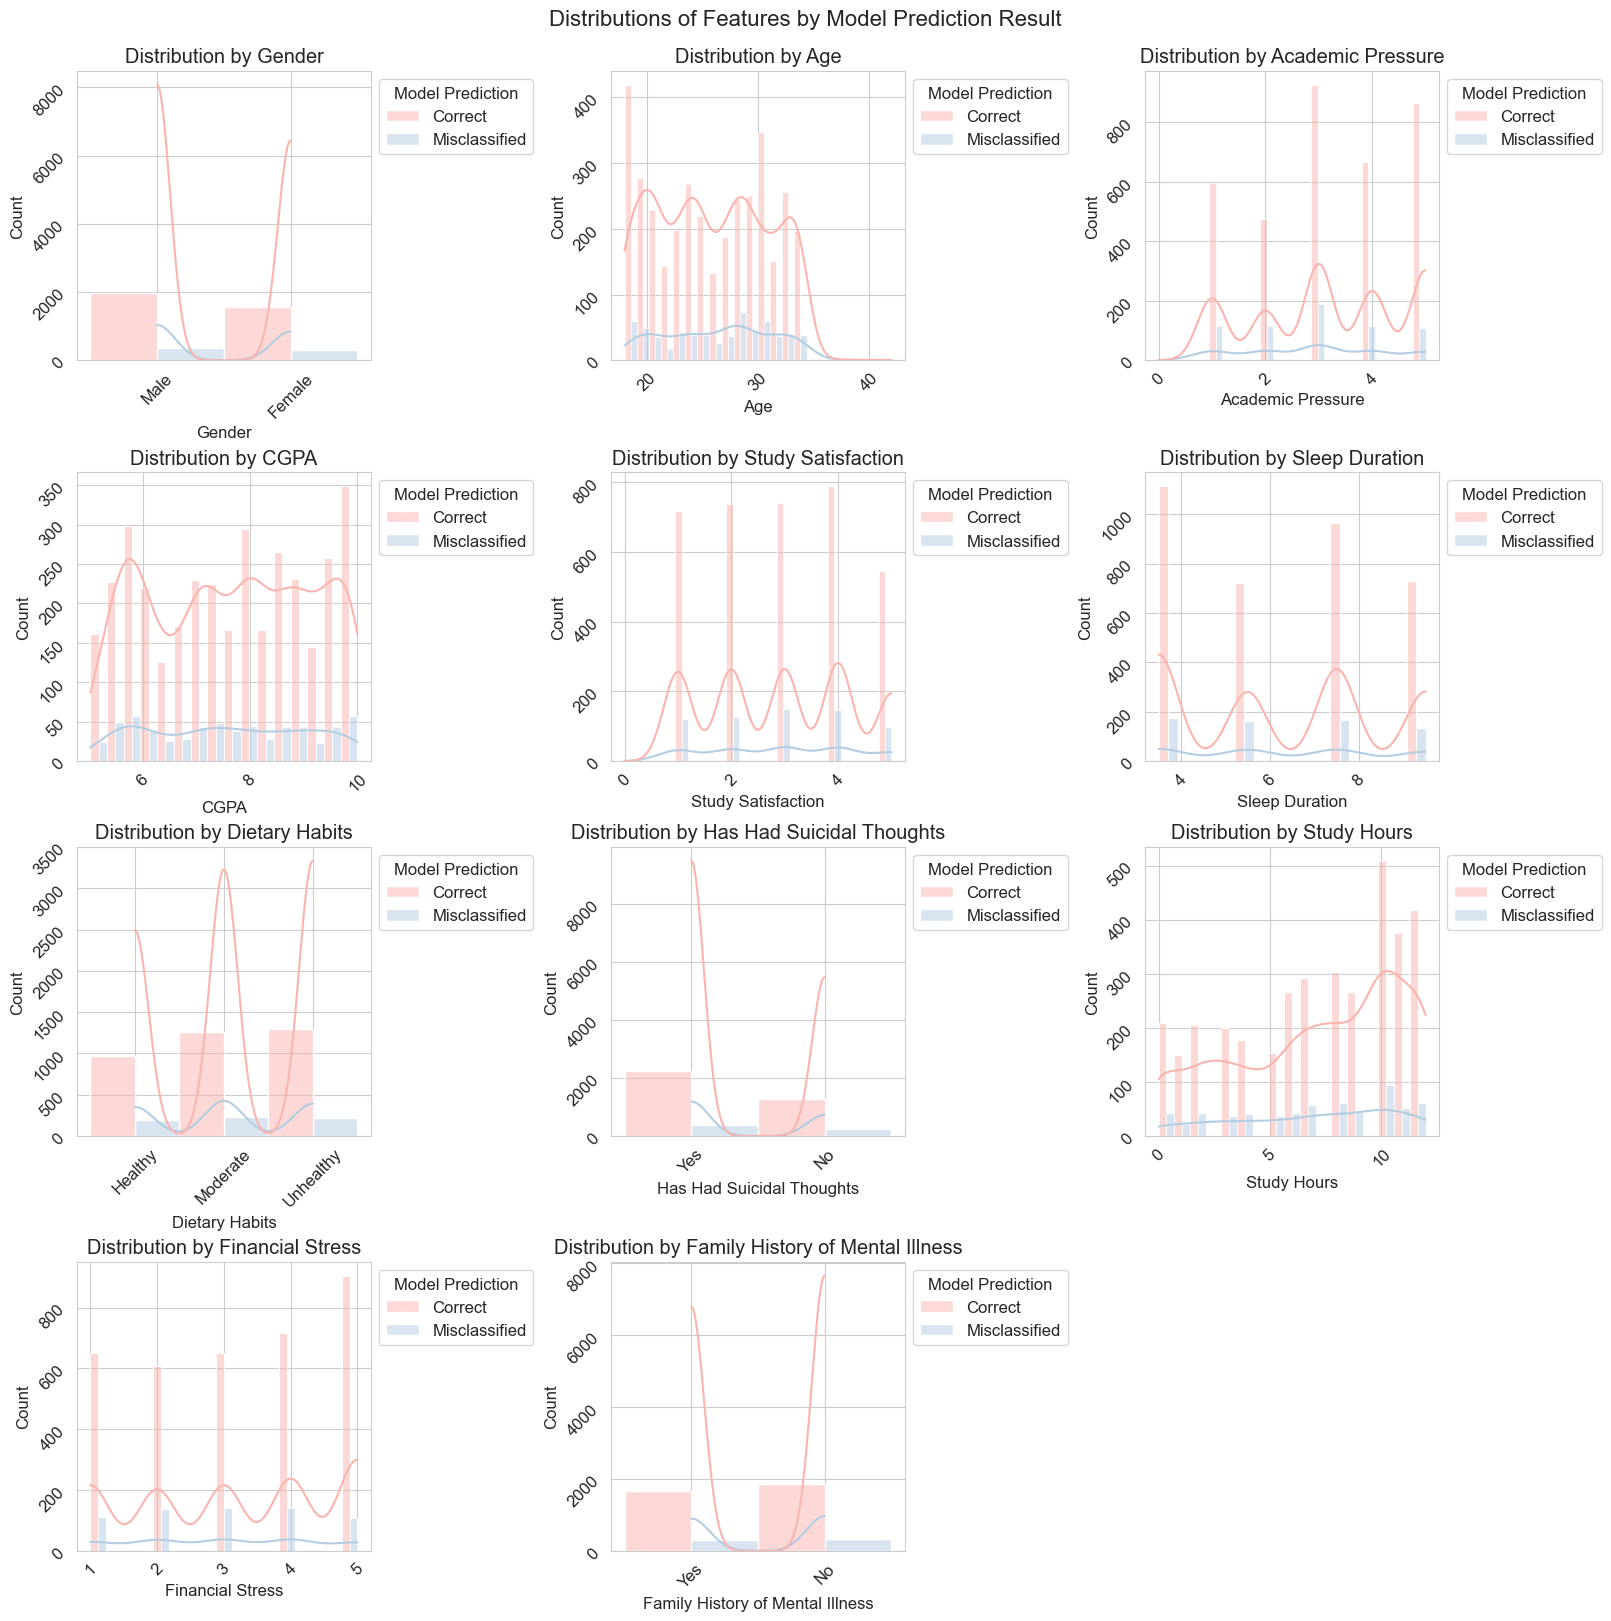

In [276]:
# Set up subplots
fig,_axes = plt.subplots(nrows=4, ncols=3, figsize=(16, 16), layout='constrained')
axes=_axes.flatten()
# Delete unused subplot and adjust spacing
fig.delaxes(axes[-1]) 

# Plot distr
i=0
for col in X_test.columns:
    ax = sns.histplot(data =misclassified, x =col, ax=axes[i], hue='Model Prediction', multiple='dodge', alpha=0.5, kde=True)
    sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
    ax.tick_params(labelrotation=45, labelsize=12)
    ax.set_title(f'Distribution by {col}')
    i=i+1

plt.suptitle('Distributions of Features by Model Prediction Result', fontsize=16, verticalalignment='center')
plt.show()

The plot shows that the distributions of `Study Hours` are different for correctly classified data and incorrectly classified data.

Now, use a decision tree on the error data to see if rules can be found to explain the errors.

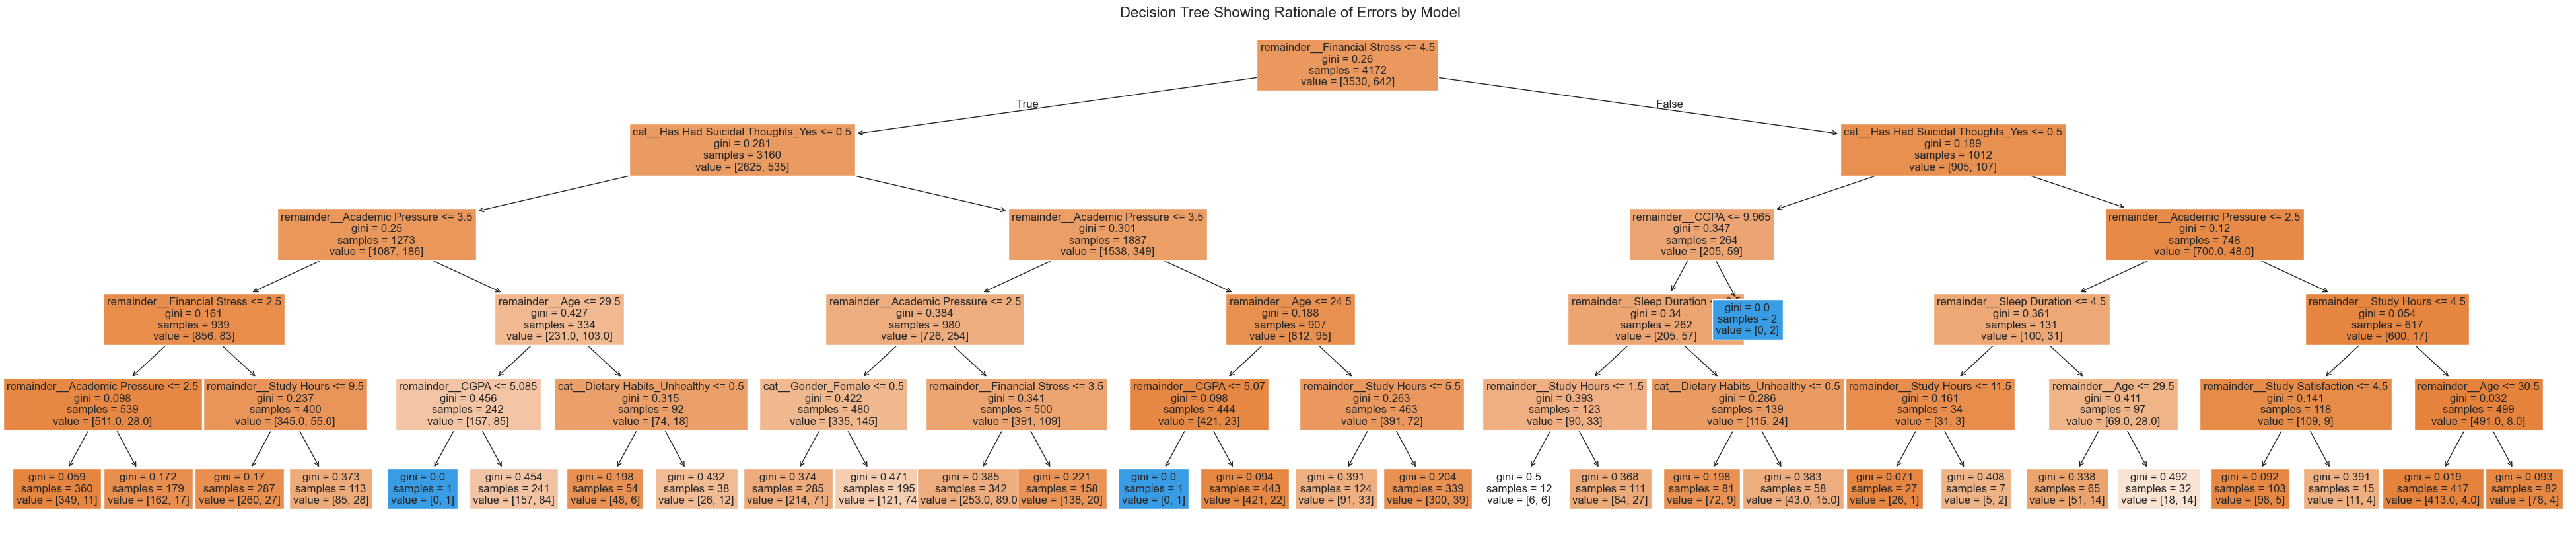

In [305]:
# Create error labels: 1 = misclassified, 0 = correct
error_labels = (final_dev_preds != y_dev).astype(int)
preprocessor_error = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ],
    remainder='passthrough'
)

meta_model = Pipeline([
    ("preprocessor", preprocessor_error),
    ("tree",  DecisionTreeClassifier(max_depth=5))
])
meta_model.fit(X_dev, error_labels)
plt.figure(figsize=(50,10))
tree_with_names = plot_tree(meta_model.named_steps['tree'],
                            feature_names = meta_model.named_steps['preprocessor'].get_feature_names_out().tolist(),
                            filled=True, fontsize=12)

plt.title('Decision Tree Showing Rationale of Errors by Model', fontsize=16)
plt.show()

The decision tree shows that ... ???

### 11. Model Interpretation and Explainability

#### 11.1 Features Importance

In [267]:
#Feature importance for the best model SVM
importance = permutation_importance(final_model, X_dev, y_dev, random_state=RANDOM_STATE)

Top 5 Features (Permutation Importance):


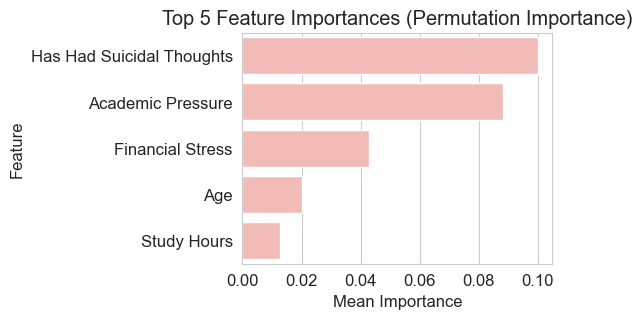

In [268]:
# Create a datafrane table of features sorted by importance
feature_names = final_model.feature_names_in_
importance_df = pd.DataFrame({k: importance[k] for k in ("importances_mean","importances_std",)},index=feature_names)\
                                 .sort_values(by="importances_mean", ascending=False)

# Plot the top 5 important features
top_n = 5
print(f"Top {top_n} Features (Permutation Importance):")
plt.figure(figsize=(4, 3))
sns.barplot(data = importance_df.head(top_n), x = "importances_mean", y = importance_df.head(top_n).index)
plt.title(f'Top {top_n} Feature Importances (Permutation Importance)')
plt.xlabel('Mean Importance')
plt.ylabel('Feature')
plt.show()

In [269]:
importance_df

,importances_mean,importances_std
Has Had Suicidal Thoughts,0.099904,0.004015
Academic Pressure,0.088303,0.001658
Financial Stress,0.042857,0.003683
Age,0.020278,0.001274
Study Hours,0.012608,0.002633
Dietary Habits,0.010259,0.002350
Study Satisfaction,0.008869,0.001604
Sleep Duration,0.003691,0.000930
CGPA,0.001342,0.001274
Gender,0.000144,0.000244


#### 11.2 Explanation of Top 5 Features
The most important 5 features are:
 - Has Had Suicidal Thoughts - This is the strongest indicator and makes perfect sense because those who are not depressed are unlikely to have had suicidal thoughts.
 - Academic Pressure - Those with higher academic pressure are more likely to be depressed.
 - Financial Stress - Those with higher financial stress are more likely to be depressed.
 - Age - Those who are younger are more prone to depression.
 - Study Hours - This may be where the errors come from as shown in the feature distribution plot of misclassified data, where the distributions of study hours for depressed and non-depressed students look different. The inital EDA suggests that those who study less are less likely to be depressed, but those who study more may not be depressed. The value of study hours is only useful when it is low. When number of study hours is high, it is not a good predictor for depression among students.

### 12. Model Validation and Testing - WIP

- Perform final evaluation on the held-out test set:
    - Report all evaluation metrics
    - Compare to baseline and earlier validation results
    - Discuss generalization
- Also check:
    - performance by subgroup (age, gender, category)
    - robustness to unseen conditions
    - potential bias
- This final test performance is your model’s actual quality.

### 13. Monitoring an Maintenance - WIP
- Explain to learners how real systems work after launch:
    - data drift detection
    - performance monitoring
    - retraining schedules
    - versioning models with MLflow/DVC
    - identifying model decay
- Capstones should include a brief section titled “How this model would be monitored in production.”



### 14. Iteration and Improvement - WIP
